In [1]:
#| label: setup-data

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np


## 1. Line equation

A line in two-dimensional space can be written as

$$
x_2 = mx_1 + c,
$$

where $m$ is the slope and $c$ is the intercept. In machine learning it is more convenient to use the **inner-product form**

$$
\vec{w}^\top\vec{x}+b=0,
\qquad
\vec{w}=\begin{pmatrix}w_1\\w_2\end{pmatrix},\quad
\vec{x}=\begin{pmatrix}x_1\\x_2\end{pmatrix}.
$$

Expanding the dot product gives $w_1x_1+w_2x_2+b=0$. Putting $x_2$ in terms of $x_1$, the equation becomes

$$
x_2 = -\frac{w_1}{w_2}x_1 - \frac{b}{w_2},
$$

leading to a slope of $-w_1/w_2$ and an intercept of $-b/w_2$. 

The vector $\vec{w}$ is the **normal** to the line. To see why, take any two points $\vec{x}^{(a)}$ and $\vec{x}^{(b)}$ on the line. Both satisfy the line equation, so

$$
\vec{w}^\top\vec{x}^{(a)}+b=0,\qquad \vec{w}^\top\vec{x}^{(b)}+b=0.
$$

Subtracting gives

$$
\vec{w}^\top(\vec{x}^{(a)}-\vec{x}^{(b)})=0.
$$

The difference $\vec{x}^{(a)}-\vec{x}^{(b)}$ is any vector that lies along the line, and its dot product with $\vec{w}$ is zero, so $\vec{w}$ is perpendicular to every direction along the line—that is, $\vec{w}$ is the normal. 

The next cell defines a line with $\vec{w}=(1,1)^\top$ and $b=-5$. We will further shift that line up and down by one unit and plot the three lines showing their equations on the plot.

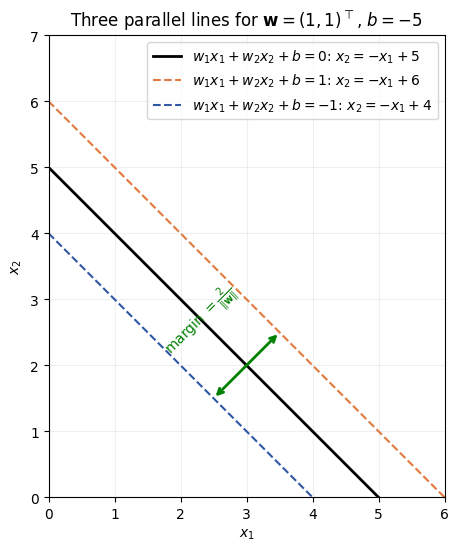

In [2]:
#| label: fig-three-lines
from matplotlib.transforms import offset_copy

w = np.array([1.0, 1.0])
b = -5.0

x1 = np.linspace(0, 6, 300)
x2 = lambda c: (c - b - w[0] * x1) / w[1]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(x1, x2(0), color='black', linewidth=2, label=r'$w_1x_1+w_2x_2+b=0$: $x_2=-x_1+5$')
ax.plot(x1, x2(1), '--', color='#e07a3f', label=r'$w_1x_1+w_2x_2+b=1$: $x_2=-x_1+6$')
ax.plot(x1, x2(-1), '--', color='#3157a4', label=r'$w_1x_1+w_2x_2+b=-1$: $x_2=-x_1+4$')

# Perpendicular margin arrow between the two support lines
ax.annotate('', xy=(3.5, 2.5), xytext=(2.5, 1.5),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2))
# Shift label 45 display-pts upper-left (perpendicular to the arrow) from its midpoint
trans = offset_copy(ax.transData, fig=fig, x=-45, y=45, units='dots')
ax.text(3.0, 2.0, r'margin $=\frac{2}{\|\mathbf{w}\|}$', color='green',
        fontsize=10, rotation=45, ha='center', va='center', transform=trans)

ax.set(xlim=(0, 6), ylim=(0, 7), xlabel='$x_1$', ylabel='$x_2$',
    title=r'Three parallel lines for $\mathbf{w}=(1,1)^\top$, $b=-5$')
ax.set_aspect('equal')
ax.legend(loc='upper right')
ax.grid(alpha=0.2)

plt.show()


## 2. Geometric distance between parallel margin lines

Consider three parallel lines with normal vector $\mathbf{w}=(1,1)^\top$ and offset $b=-5$:

Central line: $g(\mathbf{x})=\mathbf{w}^\top\mathbf{x}+b=0$, i.e. $x_2=-x_1+5$;

Upper parallel line: $g(\mathbf{x})=+1$, i.e. $x_2=-x_1+6$;

Lower parallel line: $g(\mathbf{x})=-1$, i.e. $x_2=-x_1+4$.

All three lines are parallel because they have the same normal vector $\mathbf{w}$ as derived earlier. Their common slope is $-w_1/w_2=-1$, and they differ only in their intercepts.

The vector $\mathbf{w}$ is perpendicular to all three lines. Therefore, the corresponding *unit* normal vector is
$\hat{\mathbf{n}}=\dfrac{\mathbf{w}}{\lVert\mathbf{w}\rVert}$  where $\lVert\mathbf{w}\rVert=\sqrt{w_1^2+w_2^2}.$


We now want to find the perpendicular distance between the two lines $g(\mathbf{x})=+1$ and $g(\mathbf{x})=-1$.

Let $\mathbf{x}{-}$ be any point on the line $g(\mathbf{x})=-1$. Moving from $\mathbf{x}{-}$ in the direction of the unit normal until reaching the line $g(\mathbf{x})=+1$ gives a point $\mathbf{x}_{+}$. If $D$ denotes the perpendicular distance between the two lines, then

$\mathbf{x}{+}=\mathbf{x}{-}+D\dfrac{\mathbf{w}}{\lVert\mathbf{w}\rVert}$.

Since the two points lie on their respective lines, $\mathbf{w}^\top\mathbf{x}_{+}+b=+1$ and $\mathbf{w}^\top\mathbf{x}_{-}+b=-1$.

Subtracting the second equation from the first gives: $2=\mathbf{w}^\top(\mathbf{x}{+}-\mathbf{x}{-})$.

Using $\mathbf{x}{+}-\mathbf{x}{-}=D\dfrac{\mathbf{w}}{\lVert\mathbf{w}\rVert}$, we obtain: $2=\mathbf{w}^\top\left(D\dfrac{\mathbf{w}}{\lVert\mathbf{w}\rVert}\right)$.

Therefore, $2=D\dfrac{\mathbf{w}^\top\mathbf{w}}{\lVert\mathbf{w}\rVert}$. Since $\mathbf{w}^\top\mathbf{w}=\lVert\mathbf{w}\rVert^2$,we get $2=D\lVert\mathbf{w}\rVert$.

Hence, $\boxed{D=\dfrac{2}{\lVert\mathbf{w}\rVert}}$.

The distance from the central line $g(\mathbf{x})=0$ to either of the two parallel lines is therefore $\boxed{\dfrac{1}{\lVert\mathbf{w}\rVert}}$.